# Human mobility - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.

> Each prompt produces roughly the matching cell in the **Lane B** notebook.


## About this data source

**US Census LODES (ground mobility).** Every year the Census links *where people live* to
*where they work*, from employment records. Free, nationwide, down to the neighbourhood.
Think of it as: *"how many people sleep in county A and work in county B?"* That commuting
shed is the ground truth for which neighbours you exchange people with daily.

- **Explore it in a browser:** <https://onthemap.ces.census.gov/> (click a county, watch the
  arrows showing where its workers come from)
- Raw files: <https://lehd.ces.census.gov/data/>

**OpenFlights (air mobility).** A volunteer-built, open database of the world's airports and
airline routes. Not passenger counts, but the *wiring diagram* of global air travel, which is
how a distant outbreak becomes a local case.

- **Explore it in a browser:** <https://openflights.org/> (search an airport, see every route
  drawn on a world map)

> The gold standard here is GLEAM (Vespignani's lab), which uses licensed OAG/IATA and
> national commuting data. These two are the free stand-ins.


## Step 1: ground mobility

> *Using US Census LODES origin-destination data (LODES8, Georgia, JT00, 2021), for*
> *Fulton County GA (FIPS 13121), rank the counties that send the most commuters in.*
> *County = first 5 digits of the block geocode; sum the S000 column. Return the top 10*
> *as a tidy table with county names (use the Census national_county2020 lookup), and*
> *plot them. Note the file is ~22 MB, so cache the aggregate.*

**Your check:** do the top feeders look like the real commuter shed for that county?


Using cached LODES aggregate: ../data/lodes_fulton_inflow_top_counties.csv


   home_county_fips          home_county  commuters_to_fulton  share_pct
0             13121    Fulton County, GA               234257      27.39
1             13089    DeKalb County, GA               119060      13.92
2             13067      Cobb County, GA               108147      12.65
3             13135  Gwinnett County, GA                86184      10.08
4             13117   Forsyth County, GA                37252       4.36
5             13063   Clayton County, GA                36714       4.29
6             13057  Cherokee County, GA                30456       3.56
7             13151     Henry County, GA                24290       2.84
8             13097   Douglas County, GA                17160       2.01
9             13223  Paulding County, GA                15033       1.76


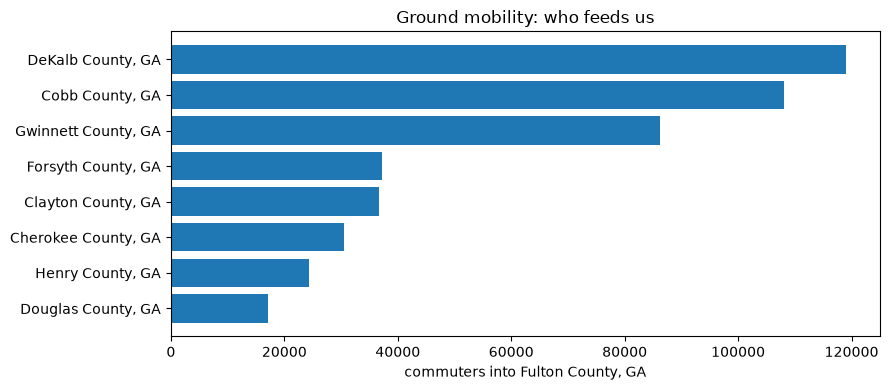

These are the neighbours to watch: their outbreak tends to reach us first.


In [1]:
import pandas as pd, matplotlib.pyplot as plt, os, io, json
import urllib.request, urllib.parse

UA = {'User-Agent': 'SISMID2026-course/1.0 (your-email@example.com)'}

def cache_path(fname):
    for p in (f'../data/{fname}', f'data/{fname}', f'./{fname}'):
        if os.path.exists(p):
            return p
    return None

def fetch(url, timeout=120):
    return urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=timeout).read()

# --- LODES aggregation ---
LIVE = False          # True downloads the 22 MB LODES file and re-aggregates
TARGET_FIPS = '13121' # Fulton County, GA

if LIVE:
    import gzip, csv
    names = {}
    for line in fetch('https://www2.census.gov/geo/docs/reference/codes2020/'
                      'national_county2020.txt').decode('utf-8','replace').splitlines()[1:]:
        p = line.split('|')
        if len(p) > 4: names[p[1]+p[2]] = f'{p[4]}, {p[0]}'
    raw = fetch('https://lehd.ces.census.gov/data/lodes/LODES8/ga/od/'
                'ga_od_main_JT00_2021.csv.gz', timeout=300)
    inflow, total = {}, 0
    with gzip.open(io.BytesIO(raw), 'rt') as fh:
        for row in csv.DictReader(fh):
            if row['w_geocode'][:5] == TARGET_FIPS:
                h = row['h_geocode'][:5]; n = int(row['S000'])
                inflow[h] = inflow.get(h, 0) + n; total += n
    top = sorted(inflow.items(), key=lambda kv: -kv[1])[:15]
    ground = pd.DataFrame([{'home_county_fips': f, 'home_county': names.get(f, '?'),
                            'commuters_to_fulton': n,
                            'share_pct': round(100*n/total, 2)} for f, n in top])
else:
    p = cache_path('lodes_fulton_inflow_top_counties.csv')
    print('Using cached LODES aggregate:', p)
    ground = pd.read_csv(p)

print(ground.head(10))

g = ground[ground['home_county_fips'].astype(str) != str(TARGET_FIPS)].head(8)  # drop within-county
plt.figure(figsize=(9,4))
plt.barh(g['home_county'][::-1], g['commuters_to_fulton'][::-1])
plt.xlabel('commuters into Fulton County, GA'); plt.title('Ground mobility: who feeds us')
plt.tight_layout(); plt.show()
print('These are the neighbours to watch: their outbreak tends to reach us first.')


## Step 2: air mobility

> *I want the countries that connect to Atlanta (ATL) as a proxy for air-importation*
> *risk. Note the OpenSky API now needs a free account and OAuth2 (anonymous gets 403),*
> *so use the free OpenFlights routes.dat + airports.dat instead: count inbound routes*
> *to ATL by origin airport, map to country, and rank the top countries. Plot the top 10*
> *excluding domestic.*

**Your check:** routes measure *structure*, not passenger volume. What would you need to
turn this into real importation risk?


216 origin airports, 43 countries connect into ATL
origin_country
United States     741
Mexico             44
Germany            15
United Kingdom     12
Canada              9
Puerto Rico         8
Bahamas             6
Jamaica             5
Italy               5
France              4
Name: n_routes, dtype: int64


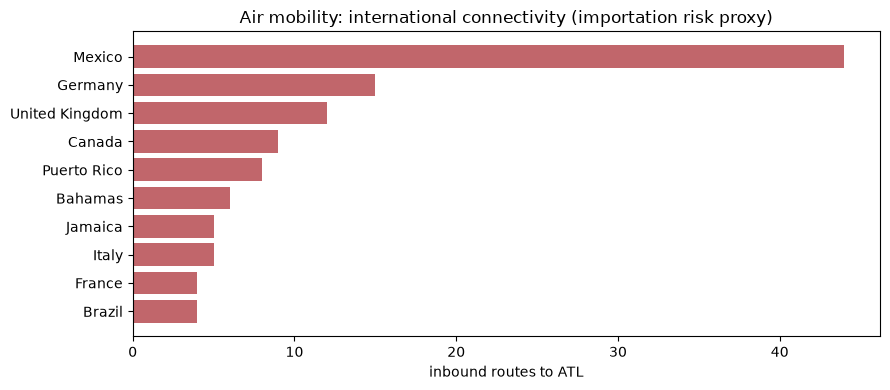

In [2]:
# --- OpenFlights connectivity ---
AIRPORT = 'ATL'
p = cache_path('openflights_atl_inbound.csv')
try:
    import csv as _csv
    ap = {}
    for line in fetch('https://raw.githubusercontent.com/jpatokal/openflights/master/'
                      'data/airports.dat').decode('utf-8','replace').splitlines():
        q = next(_csv.reader([line]))
        if len(q) > 4 and q[4] not in ('', '\\N'): ap[q[4]] = {'city': q[2], 'country': q[3]}
    rows = {}
    for line in fetch('https://raw.githubusercontent.com/jpatokal/openflights/master/'
                      'data/routes.dat').decode('utf-8','replace').splitlines():
        q = next(_csv.reader([line]))
        if len(q) > 4 and q[4] == AIRPORT and q[2] in ap:
            k = (ap[q[2]]['country'], q[2], ap[q[2]]['city'])
            rows[k] = rows.get(k, 0) + 1
    air = pd.DataFrame([{'origin_country': c, 'origin_airport': s, 'origin_city': ci,
                         'n_routes': n} for (c, s, ci), n in rows.items()])
except Exception as e:
    print('Live OpenFlights pull failed:', e, '-> using cache', p)
    air = pd.read_csv(p)

by_country = (air.groupby('origin_country')['n_routes'].sum()
                 .sort_values(ascending=False))
print(f'{len(air)} origin airports, {by_country.size} countries connect into {AIRPORT}')
print(by_country.head(10))

intl = by_country.drop(labels=['United States'], errors='ignore').head(10)
plt.figure(figsize=(9,4))
plt.barh(intl.index[::-1], intl.values[::-1], color='#C1666B')
plt.xlabel(f'inbound routes to {AIRPORT}')
plt.title('Air mobility: international connectivity (importation risk proxy)')
plt.tight_layout(); plt.show()


## Step 3: sanity-check and save

> *Report row counts for both tables, confirm the commuter shares sum sensibly, and save*
> *both to tidy CSVs.*


In [3]:
print('ground rows:', len(ground), '| air rows:', len(air))
print('ground share of total accounted for:', round(ground['share_pct'].sum(), 1), '%')
ground.to_csv('mobility_ground_top_counties.csv', index=False)
air.to_csv('mobility_air_inbound.csv', index=False)
print('saved mobility_ground_top_counties.csv and mobility_air_inbound.csv')


ground rows: 15 | air rows: 216
ground share of total accounted for: 88.6 %
saved mobility_ground_top_counties.csv and mobility_air_inbound.csv


## Reflection

- Ground = which neighbours seed you; air = which distant places import risk.
- Both are free proxies for GLEAM's licensed OAG / IATA / commuting data.
- Feeds the ARGONet network idea in the 1:30 session.
